# 4.6 Inverse Problem (manual)

In [1]:
using CairoMakie
using NonlinearSolve
using Zygote
using Optimization
using OptimizationOptimisers
using ForwardDiff

In [2]:
mutable struct Dual <: Number
    v::Float64 #value of the function
    ∂::Float64 #its derivative
end

import Base:+,-,*,sin,^,/,cos
+(a::Dual,b::Dual)=Dual(a.v+b.v,a.∂+b.∂) 
+(a::Dual,b::Number)=Dual(a.v+b,a.∂) 
+(a::Number,b::Dual)=Dual(a+b.v,b.∂) 
-(a::Dual,b::Dual)=Dual(a.v-b.v,a.∂-b.∂) 
-(a::Number,b::Dual)=Dual(a-b.v,-b.∂) 
-(a::Dual,b::Number)=Dual(a.v-b,a.∂) 
*(a::Dual,b::Dual)=Dual(a.v*b.v,a.v*b.∂+b.v*a.∂) 
*(a::Number,b::Dual)=Dual(a*b.v,a*b.∂) 
/(a::Dual,b::Dual)=Dual(a.v/b.v,(b.v*a.∂-a.v*b.∂)/(b.v)^2) 
/(a::Number,b::Dual)=Dual(a/b.v,(-a*b.∂)/(b.v)^2) 
#*(a::Float64,b::Dual)=Dual(a*b.v,a*b.∂) 
^(a::Dual,n::Integer)=Dual(a.v^n,n*a.v^(n-1)*a.∂) 
sin(a::Dual)=Dual(sin(a.v),cos(a.v)*a.∂) 
cos(a::Dual)=Dual(cos(a.v),-sin(a.v)*a.∂) 

cos (generic function with 31 methods)

In the first week of this course we considered a cylinder with volume $V$.  The problem was that we wanted to find $r$ such that we minimise the surface area $A$.  Thus far, we have assumed that $V=1$.  Now we are going to look at the more complicated example where $V$ is a variable.  We want to find $V$ with $r_{min}$ is some desired value.  We want to ensure we are able to pick a $r$ such that minimize $A$.  In this problem, $V$ does not need to be 1, but it can be whatever it needs to be.  

We know from geometry that 

$V=\pi r^2 h$

$h=\frac{V}{\pi r^2}$

The area $A$ which makes up the cylinder is

$A=\pi r^2+\pi r^2+2\pi r h$

$A(r,V)=2\pi r^2+\frac{2 V}{r}$

To minimize the area for a given $V$, we have to find $r$ where

$f(r,V)=dA(r)/dr=4\pi r-\frac{2 V}{r^2}=0$

We want to find $r$ such that $f(r)=0$.  For this example, this nonlinear is actually solveable. However, it is usually not possible to explicitly solve for the relationship between $r$ and $V$.  In order to illustrate the process, we will assume that you need to solve for $f(r,V)=0$ using some (Newton-Raphson) technique. 

In [3]:
f(r,V)=4π*r-2*V*(1/r)*(1/r)
dfdr_plot(r,V)=4*π+4V/r^3

dfdr_plot (generic function with 1 method)

We can see how $r$ changes with $V$ by using Newton Raphson method

$
r_{i+1}=r_{i}-f(r_i,V)/(\partial f/\partial r(r_i,V))
$

to solve for 

$f(r,V)=4πr-2V/r^2=0$.

In [4]:
Vvec=0.5:0.25:2.0
rvec=zeros(length(Vvec))
r=0.3
for n=1:length(Vvec)
    while abs(f(r,Vvec[n]))>1.0e-6
        r-=f(r,Vvec[n])/dfdr_plot(r,Vvec[n])
    end
    rvec[n]=r
end

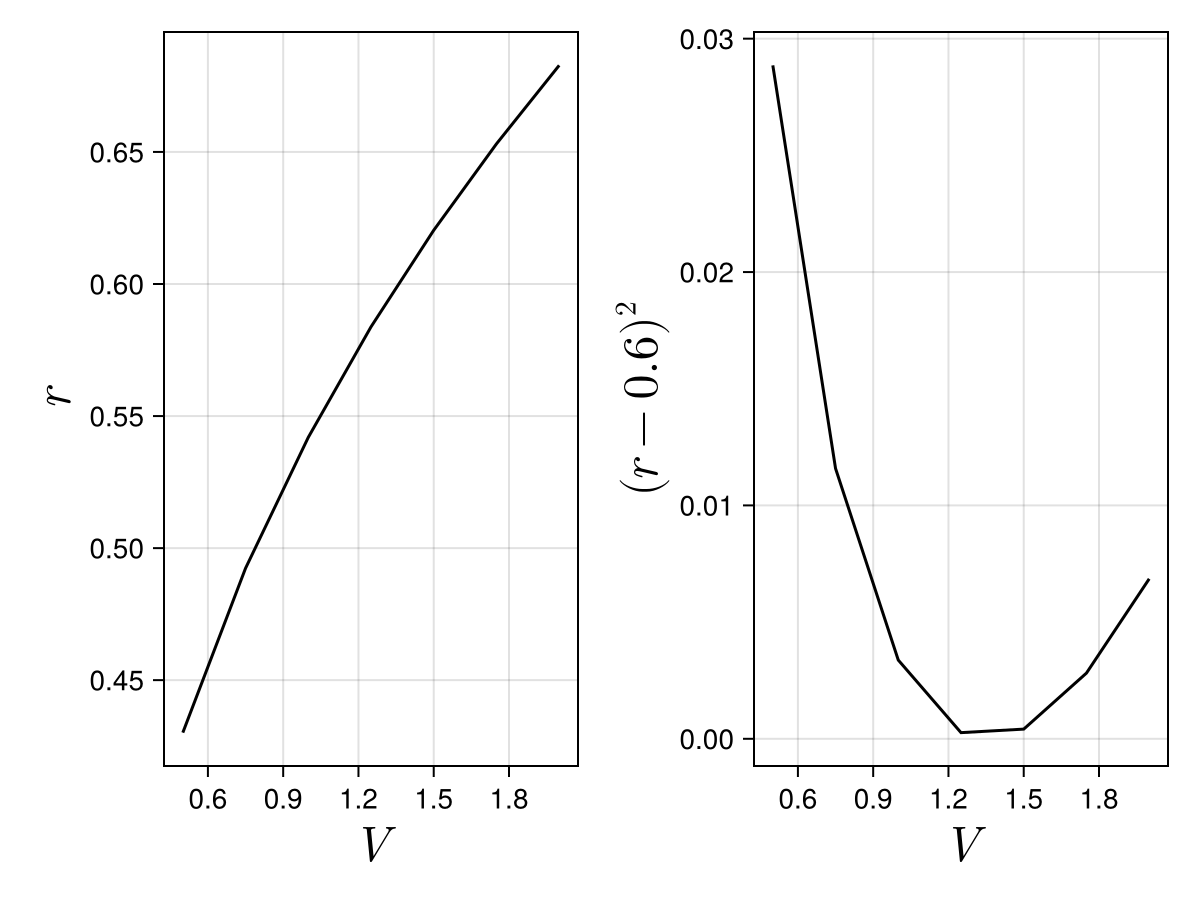

CairoMakie.Screen{IMAGE}


In [5]:
fig = Figure()
ax1 = Axis(fig[1, 1], xlabel = L"V", ylabel = L"r",
    xlabelsize=25,
    ylabelsize=25,
    backgroundcolor = :transparent)
lines!(ax1,Vvec,rvec;label="Data",color=:black)
#axislegend(ax1;position = :rt)

ax2 = Axis(fig[1, 2], xlabel = L"V", ylabel = L"(r-0.6)^2",
    xlabelsize=25,
    ylabelsize=25,
    backgroundcolor = :transparent)
lines!(ax2,Vvec,(rvec.-0.6).^2;label="Data",color=:black)
save("../figures/04p06InverseProblemManual.svg",fig)
display(fig)

In this problem, we would like to find the value of $V$ when $r=0.6$.  From the plots above,  wwe can clearly see how $r$ changes with $V$ on the plot on the left.  On the right plot, one can clearly see that if we want $r_{min}=0.6$, then the volume $V\approx 1.3$.

In summary, we can cast this problem as a "constrained" optimisation problem.  So we are trying to minimise the cost function 

$S=(r(V)-0.6)^2$

(remember that $r$ is function of $V$) subject to the constraint

$f(r,V)=4πr-2V/r^2=0$.


---

We will now show how we can solve this problem "manually" (level 1).  We will use Newton-Raphson method to solve for $r$ for $V=1.0$, just to test that everything is working fine.  We know that the answer shhould be $r\approx 0.5419...$. We will use Forward Mode Automatic Differentiation using Dual numbers.



In [6]:
r=Dual(1.0,1.0)
V=Dual(1.0,0.0)
f(r,V)

while abs(f(r,V).v)>1.0e-12
#for i=1:50
        println(r)
        r=r-f(r,V).v/f(r,V).∂
end

Dual(1.0, 1.0)
Dual(0.3621795105078358, 1.0)
Dual(0.4727153376004709, 1.0)
Dual(0.5323948682518493, 1.0)
Dual(0.5417564911696957, 1.0)
Dual(0.5419260170637374, 1.0)


The loss function is 

$S=(r(V)-0.6)^2$

In order to use gradient descent to  minise $S$, we neeed to calculate 

$\frac{\partial S}{\partial V}=\frac{\partial S}{\partial r}\frac{\partial r}{\partial V}$

Finding $\frac{\partial S}{\partial r}$ is easy
$
\frac{\partial S}{\partial x}=2(r(V)-0.6)
$

Therefore

$\frac{\partial S}{\partial V}=2(r(V)-0.6)\frac{\partial r}{\partial V}$

$\frac{\partial r}{\partial V}$ is usually very difficult to calculate.  To compute $\frac{\partial r}{\partial V}$, we need to use the implicit function theorem

$\frac{d f}{d V}=\frac{\partial f}{\partial r}\frac{ \partial r}{\partial V}+\frac{\partial  f}{\partial  V}=0$

Therefore 

$
\frac{ \partial r}{\partial V}=-\frac{\partial  f}{\partial  V}/\frac{\partial f}{\partial r}$

We can use Forward Diff Automatic Differentiation to find ${\partial r}/{\partial  V}$

In [7]:
dfdr=f(r,V).∂
dfdV=f(Dual(r.v,0.0),Dual(V.v,1.0)).∂
drdV=-dfdV/dfdr

0.18064202337976296

In [8]:
r=Dual(1,1)

Dual(1.0, 1.0)

In [9]:
S(r)=(r-0.6)^2
dSdr=S(Dual(r.v,1.0)).∂
#dSdr=((Dual(r.v,1.0)-0.6).^2).∂
dSdV=dSdr*drdV

0.14451361870381038

In [10]:
r=Dual(1.0,1.0)
V=Dual(1.0,0.0)

α=0.5


for n=1:5000
    
    #Solve for r
    while abs(f(r,V).v)>1.0e-6
        r=r-f(r,V).v/f(r,V).∂
    end

    #Using the implicit function formula to find drdV and then to calculate dSdV
    dfdr=f(r,V).∂
    dfdV=f(Dual(r.v,0.0),Dual(V.v,1.0)).∂
    drdV=-dfdV/dfdr
    
    dSdr=S(Dual(r.v,1.0)).∂
    dSdV=dSdr*drdV

    #Gradient Descent
    V.v=V.v-α*dSdV
    println(V.v)
end

1.0104905921956542
1.0205696826117423
1.0302611559174897
1.0395868747922419
1.048566909285886
1.0572197338171698
1.0655623972100745
1.0736106701461317
1.0813791735941167
1.0888814911330045
1.0961302675699574
1.1031372958428838
1.1099135938644622
1.1164694726944648
1.1228145972067354
1.1289580402361792
1.1349083310417993
1.1406734987980058
1.1462611117233104
1.1516783123692582
1.1569318495199836
1.1620281070916598
1.1669731303693742
1.1717726498749916
1.1764321031220855
1.1809566544819445
1.1853512133571413
1.1896204508354504
1.1937688149764532
1.1978005448654458
1.2017196835538944
1.2055300899922863
1.209235450049554
1.2128392867030162
1.2163449694738306
1.2197557231750633
1.2230746360325573
1.2263046672326459
1.2294486539453515
1.2325093178669035
1.2354892713211527
1.2383910229556667
1.241216983064913
1.2439694685699207
1.2466507076811169
1.2492628442686147
1.2518079419620682
1.2542879880002586
1.2567048968488257
1.2590605136029798
1.2613566171906063
1.263594923389884
1.26577708767437

---

**Class Demo 01:**

You can given that 

$f(x,\alpha)=0.5-\exp(-\alpha x^2)$

Find the value of $\alpha$ such that $x=0.5$